In [44]:
import pyodbc
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Définir les informations de connexion
server = 'LAPTOP-HED7JE2F'
database = 'PGS_STAGE_DW'
username = 'sa'
password = 'sa@123@123'

# Établir la connexion
try:
    connection = pyodbc.connect('DRIVER={SQL Server};SERVER='+server+';DATABASE='+database+';UID='+username+';PWD='+password)
    print("Connexion réussie à la base de données SQL Server")
    
    # Définir la requête SQL
    query = """
    SELECT f.ordered_quantity, r.start_time, r.product_group_code
    FROM fact_sales AS f
    INNER JOIN dim_order_recipe AS r ON f.FK_ORDER_RECIPE = r.pk_order_recipe
    WHERE r.product_group_code = 'AV' 
    """
    
    # Exécuter la requête SQL et récupérer les résultats dans un DataFrame pandas
    result = pd.read_sql(query, connection)
    
    # Convertir la colonne de dates en datetime
    result['start_time_date'] = pd.to_datetime(result['start_time'])
    
    # Définir la colonne 'start_time_date' comme index
    result.set_index('start_time_date', inplace=True)
    
    # Regrouper par mois et calculer la somme des quantités commandées pour chaque mois
    result = result.resample('M').sum(numeric_only=True).reset_index()
    
    # Afficher les résultats
    print("Résultats de la série temporelle regroupés par mois :")
    print(result)

except pyodbc.Error as e:
    print("Erreur lors de la connexion à la base de données SQL Server :", e)

# Convertir la colonne de dates en format de mois
result['month'] = result['start_time_date'].dt.to_period('M')

# Agréger les données par mois et calculer la somme de la quantité
monthly_sum = result.groupby('month')['ordered_quantity'].sum().reset_index()

# Stocker les sommes mensuelles dans un fichier CSV
monthly_sum.to_csv("monthly_sum_AV.csv", index=False)

import pandas as pd
import numpy as np

# Read the CSV file
df = pd.read_csv('monthly_sum_AV.csv')

# Convert the 'month' column to datetime
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Add 1 month before the first month in the DataFrame
start_date = df['month'].min()
extra_months = pd.date_range(start=start_date - pd.DateOffset(months=4), periods=4, freq='M')
extra_data = pd.DataFrame({'month': extra_months, 'ordered_quantity': np.nan})
df = pd.concat([extra_data, df])

# Replace outliers
def replace_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 0.5 * IQR
    upper_bound = Q3 + 0.5 * IQR
    df[column] = df[column].apply(lambda x: x if (x >= lower_bound and x <= upper_bound) else np.nan)
    return df

df = replace_outliers(df, 'ordered_quantity')

# Compute median for each month
monthly_medians = df.groupby(df['month'].dt.month)['ordered_quantity'].median()

# Function to impute missing values based on month
def impute_missing_values_by_month(df, column):
    df[column] = df.apply(lambda row: monthly_medians[row['month'].month] if pd.isna(row[column]) else row[column], axis=1)
    return df

# Impute missing values
df = impute_missing_values_by_month(df, 'ordered_quantity')

# Save the modified DataFrame
df.to_csv('monthly_sum_AV_modified.csv', index=False)

print(df)

# Read and display the modified file
df_modified = pd.read_csv('monthly_sum_AV_modified.csv', parse_dates=['month'], index_col=['month'])
print(df_modified.head())


Connexion réussie à la base de données SQL Server
Résultats de la série temporelle regroupés par mois :
   start_time_date  ordered_quantity
0       2021-10-31            992000
1       2021-11-30           3100883
2       2021-12-31           1909945
3       2022-01-31           1312000
4       2022-02-28           1120000
5       2022-03-31           3584000
6       2022-04-30           1760000
7       2022-05-31           4288622
8       2022-06-30           2624000
9       2022-07-31           3616000
10      2022-08-31           3840000
11      2022-09-30           2804050
12      2022-10-31           5412554
13      2022-11-30           3680000
14      2022-12-31           2848000
15      2023-01-31           2976000
16      2023-02-28           2304000
17      2023-03-31           2804000
18      2023-04-30           6906683
19      2023-05-31           5472000
20      2023-06-30           7167914
21      2023-07-31           7101584
22      2023-08-31           8160000
23      

C:\Users\user\AppData\Local\Temp\ipykernel_51044\1342342588.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql(query, connection)
C:\Users\user\AppData\Local\Temp\ipykernel_51044\1342342588.py:40: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  result = result.resample('M').sum(numeric_only=True).reset_index()
C:\Users\user\AppData\Local\Temp\ipykernel_51044\1342342588.py:69: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  extra_months = pd.date_range(start=start_date - pd.DateOffset(months=4), periods=4, freq='M')


In [45]:

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


print("gaaaas")


df = pd.read_csv('monthly_sum_AV_modified.csv', parse_dates = ['month'], index_col = ['month'])
 
df.head()



    

gaaaas


,ordered_quantity
month,
2021-06-30,2624000.0
2021-07-31,3616000.0
2021-08-31,3840000.0
2021-09-30,2804050.0
2021-10-01,5412554.0


Statistiques ADF : -4.299211257160687
p-value : 0.0004456114721759625
Valeurs Critiques :
	1%: -3.7238633119999998
	5%: -2.98648896
	10%: -2.6328004


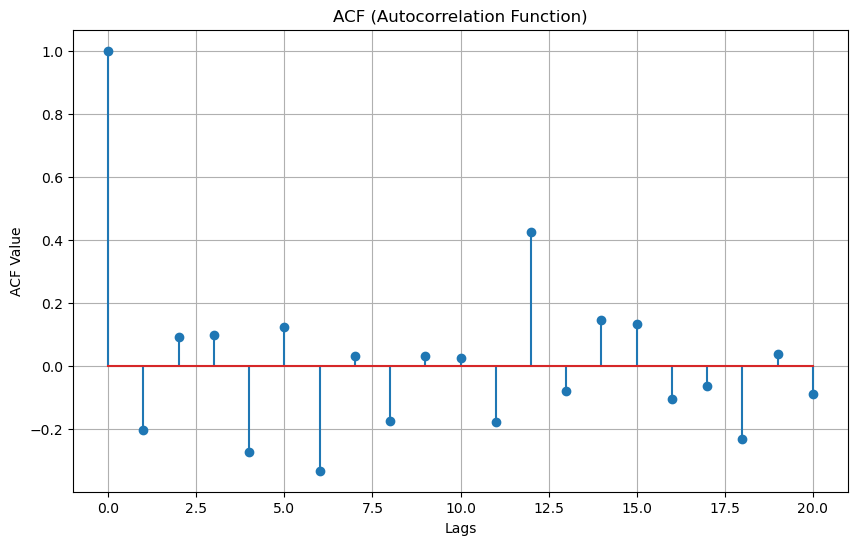

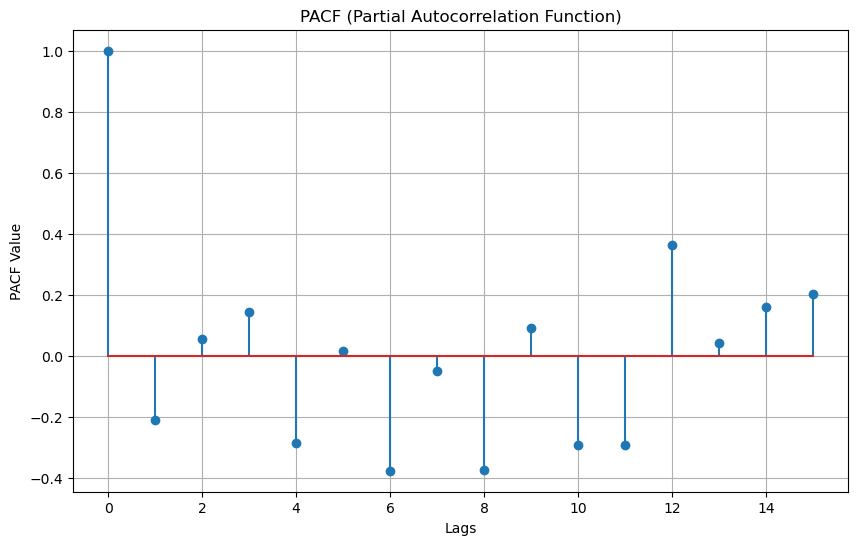

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf

# Vérification de la stationnarité avec le test ADF
result = adfuller(df['ordered_quantity'])

print('Statistiques ADF : {}'.format(result[0]))
print('p-value : {}'.format(result[1]))
print('Valeurs Critiques :')
for key, value in result[4].items():
    print('\t{}: {}'.format(key, value))

# Affichage de l'ACF (Autocorrelation Function)
acf_values = acf(df['ordered_quantity'], nlags=20)  # Ajustez nlags selon la taille de vos données

# Tracer l'ACF
plt.figure(figsize=(10, 6))
plt.stem(range(len(acf_values)), acf_values, use_line_collection=True)
plt.title('ACF (Autocorrelation Function)')
plt.xlabel('Lags')
plt.ylabel('ACF Value')
plt.grid()
plt.show()

# Affichage de la PACF (Partial Autocorrelation Function)
# Ajustez nlags pour qu'il soit inférieur à 50 % de la taille de votre échantillon
pacf_values = pacf(df['ordered_quantity'], nlags=15)

# Tracer la PACF
plt.figure(figsize=(10, 6))
plt.stem(range(len(pacf_values)), pacf_values, use_line_collection=True)
plt.title('PACF (Partial Autocorrelation Function)')
plt.xlabel('Lags')
plt.ylabel('PACF Value')
plt.grid()
plt.show()


In [47]:
    
#############################log application ##########################

df_log = np.log(df)
df_log.head()

,ordered_quantity
month,
2021-06-30,14.780210
2021-07-31,15.100879
2021-08-31,15.160983
2021-09-30,14.846575
2021-10-01,15.504232


MAE: 3149113.547407547
MSE: 9917661439020.37
RMSE: 3149231.880795755
R²: -89776039347724.97
                 Date      Forecast type
2023-10-01 2024-06-01  3.126970e+06   DS
2023-11-01 2024-07-01  3.167352e+06   DS
2023-12-01 2024-08-01  3.115063e+06   DS
2024-01-01 2024-09-01  3.176673e+06   DS
2024-02-01 2024-10-01  3.121976e+06   DS
2024-03-01 2024-11-01  3.179659e+06   DS
2024-04-01 2024-12-01  3.125047e+06   DS
2024-05-01 2025-01-01  3.180287e+06   DS
2024-06-01 2025-02-01  3.126667e+06   DS
2024-07-01 2025-03-01  3.180048e+06   DS
2024-08-01 2025-04-01  3.127732e+06   DS
2024-09-01 2025-05-01  3.179498e+06   DS
2024-10-01 2025-06-01  3.128576e+06   DS
2024-11-01 2025-07-01  3.178846e+06   DS
2024-12-01 2025-08-01  3.129326e+06   DS
2025-01-01 2025-09-01  3.178167e+06   DS
2025-02-01 2025-10-01  3.130028e+06   DS
2025-03-01 2025-11-01  3.177491e+06   DS
2025-04-01 2025-12-01  3.130700e+06   DS
2025-05-01 2026-01-01  3.176828e+06   DS


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


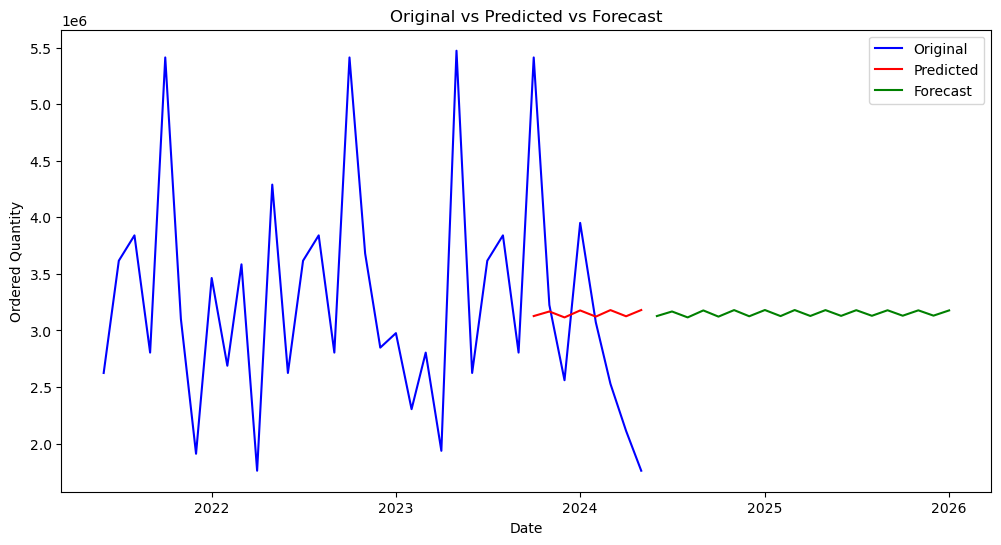

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Supposons que df_log est votre DataFrame contenant les données

# Convertir l'index en DatetimeIndex si nécessaire
df_log.index = pd.to_datetime(df_log.index)

# Rééchantillonner les données pour obtenir une fréquence mensuelle tout en gardant les valeurs d'origine
df_log = df_log.resample('MS').mean()

# Remplir les valeurs manquantes avec la méthode d'interpolation
df_log = df_log.interpolate(method='linear')

# Décomposer la série saisonnière
decomposition = seasonal_decompose(df_log)

# Définir la proportion de données à utiliser pour l'apprentissage
train_size = 0.8  # 70% des données pour l'apprentissage
split_index = int(len(df_log) * train_size)

# Diviser les données en ensembles d'apprentissage et de test
train_data = df_log.iloc[:split_index]
test_data = df_log.iloc[split_index:]

# Créer et ajuster le modèle ARIMA sur l'ensemble d'apprentissage
model = ARIMA(train_data, order=(2, 0,3))
results = model.fit()

# Effectuer des prédictions sur l'ensemble de test
predictions = results.predict(start=test_data.index[0], end=test_data.index[-1])

# Convertir les prédictions en antilogarithme
predictions_antilog = np.exp(predictions)

# Calcul des métriques d'évaluation
mae = mean_absolute_error(test_data, predictions_antilog)
mse = mean_squared_error(test_data, predictions_antilog)
rmse = np.sqrt(mse)
r2 = r2_score(test_data, predictions_antilog)

# Afficher les métriques
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Prédire les 20 mois à venir
forecast = results.forecast(steps=20)
forecast_antilog = np.exp(forecast)

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_dates = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast_antilog})

# Ajouter une colonne "type" au DataFrame avec la valeur "DS"
forecast_df['type'] = 'DS'

# Afficher le DataFrame avec les prédictions en antilogarithme et la colonne "type"
print(forecast_df)

# Tracer les courbes
plt.figure(figsize=(12, 6))

# Courbe de la série originale
plt.plot(df_log.index, np.exp(df_log['ordered_quantity']), label='Original', color='blue')

# Courbe des prédictions
plt.plot(test_data.index, predictions_antilog, label='Predicted', color='red')

# Courbe des prévisions futures
plt.plot(forecast_df['Date'], forecast_df['Forecast'], label='Forecast', color='green')

# Ajouter des légendes et des titres
plt.title('Original vs Predicted vs Forecast')
plt.xlabel('Date')
plt.ylabel('Ordered Quantity')
plt.legend()

# Afficher la courbe
plt.show()


In [ ]:
################################    modele a retenir #########################################

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


MAE: 0.2445717034305801
MSE: 0.13354567038169424
RMSE: 0.365439010481495
R²: -0.20887382903944696
            lower ordered_quantity  upper ordered_quantity   Forecast type
2024-06-01               15.370122               15.637861  15.503991   DS
2024-07-01               14.832912               15.097892  14.965402   DS
2024-08-01               14.372752               14.638420  14.505586   DS
2024-09-01               14.915741               15.181557  15.048649   DS
2024-10-01               14.665782               14.931702  14.798742   DS
2024-11-01               14.941918               15.207999  15.074959   DS
2024-12-01               14.266862               14.533475  14.400168   DS
2025-01-01               15.160549               15.422679  15.291614   DS
2025-02-01               14.679214               14.898990  14.789102   DS
2025-03-01               14.999123               15.218980  15.109051   DS
2025-04-01               15.059080               15.278983  15.169032   DS
20

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


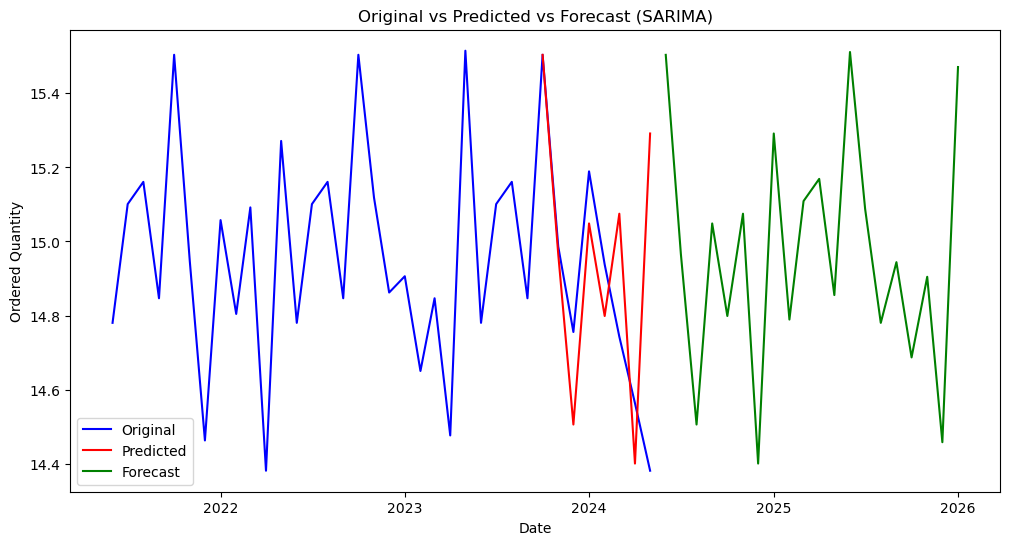

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Supposons que df_log est votre DataFrame contenant les données

# Convertir l'index en DatetimeIndex si nécessaire
df_log.index = pd.to_datetime(df_log.index)

# Rééchantillonner les données pour obtenir une fréquence mensuelle tout en gardant les valeurs d'origine
df_log = df_log.resample('MS').mean()

# Remplir les valeurs manquantes avec la méthode d'interpolation
df_log = df_log.interpolate(method='linear')

# Définir la proportion de données à utiliser pour l'apprentissage
train_size = 0.8  # 70% des données pour l'apprentissage
split_index = int(len(df_log) * train_size)

# Diviser les données en ensembles d'apprentissage et de test
train_data = df_log.iloc[:split_index]
test_data = df_log.iloc[split_index:]

# Créer et ajuster le modèle SARIMA sur l'ensemble d'apprentissage
# (p,d,q) x (P,D,Q,s) où s est la périodicité saisonnière, par exemple 12 pour les données mensuelles
model = SARIMAX(train_data, order=(3, 0, 2), seasonal_order=(3, 0, 2, 12))
results = model.fit()

# Effectuer des prédictions sur l'ensemble de test
predictions = results.predict(start=test_data.index[0], end=test_data.index[-1])

# Calcul des métriques d'évaluation
mae = mean_absolute_error(test_data, predictions)
mse = mean_squared_error(test_data, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test_data, predictions)

# Afficher les métriques
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Prédire les 20 mois à venir
forecast = results.get_forecast(steps=20)
forecast_df = forecast.conf_int()
forecast_df['Forecast'] = forecast.predicted_mean

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_df.index = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]

# Ajouter une colonne "type" au DataFrame avec la valeur "DS"
forecast_df['type'] = 'DS'

# Afficher le DataFrame avec les prédictions
print(forecast_df)

# Tracer les courbes
plt.figure(figsize=(12, 6))

# Courbe de la série originale
plt.plot(df_log.index, df_log['ordered_quantity'], label='Original', color='blue')

# Courbe des prédictions
plt.plot(test_data.index, predictions, label='Predicted', color='red')

# Courbe des prévisions futures
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast', color='green')

# Ajouter des légendes et des titres
plt.title('Original vs Predicted vs Forecast (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Ordered Quantity')
plt.legend()

# Afficher la courbe
plt.show()


In [67]:
import numpy as np
import pandas as pd
import pyodbc

# Assuming results and df_log are already defined in your session

# Prédire les 20 mois à venir
forecast = results.forecast(steps=20)

# Flatten the forecast if it's not 1D
if forecast.ndim > 1:
    forecast = forecast.flatten()

# Convertir les prédictions en antilogarithme
forecast_antilog = np.exp(forecast)

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_dates = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast_antilog})

# Ajouter une colonne "type" au DataFrame avec la valeur "UL"
forecast_df['type'] = 'AV'

# Afficher le DataFrame
print(forecast_df)

# SQL Server connection details (ensure they are correct)
server = 'LAPTOP-HED7JE2F'
database = 'PGS_STAGE_DW'
username = 'sa'
password = 'sa@123@123'

# Establish connection
conn = pyodbc.connect(f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password}')
cursor = conn.cursor()

# Backup the existing table if it exists
cursor.execute("SELECT COUNT(*) FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_NAME = 'dim_pred_orders_AV'")
table_exists = cursor.fetchone()[0]

if table_exists:
    # Backup existing table
    cursor.execute("SELECT * INTO dim_pred_orders_AV_backup FROM dim_pred_orders_AV")
    cursor.execute("DROP TABLE dim_pred_orders_AV")
    print("Existing table backed up and dropped successfully.")

# Create new table for forecast data
create_table_query = '''
CREATE TABLE dim_pred_orders_AV (
    Date DATE,
    Forecast FLOAT,
    type NVARCHAR(50),
    PRIMARY KEY (Date, Forecast, type)
)
'''
cursor.execute(create_table_query)
print("New table created successfully.")

# Insert forecast data
data_to_insert = [tuple(row) for row in forecast_df.values]
insert_query = '''
INSERT INTO dim_pred_orders_AV (Date, Forecast, type)
VALUES (?, ?, ?)
'''
cursor.executemany(insert_query, data_to_insert)

# Commit the transaction and close the connection
conn.commit()
conn.close()

print("Forecast data successfully inserted into dim_pred_orders_AV.")


                 Date      Forecast type
2023-10-01 2024-06-01  5.411254e+06   AV
2023-11-01 2024-07-01  3.157849e+06   AV
2023-12-01 2024-08-01  1.993865e+06   AV
2024-01-01 2024-09-01  3.431985e+06   AV
2024-02-01 2024-10-01  2.673081e+06   AV
2024-03-01 2024-11-01  3.523476e+06   AV
2024-04-01 2024-12-01  1.794377e+06   AV
2024-05-01 2025-01-01  4.375861e+06   AV
2024-06-01 2025-02-01  2.647436e+06   AV
2024-07-01 2025-03-01  3.645673e+06   AV
2024-08-01 2025-04-01  3.871032e+06   AV
2024-09-01 2025-05-01  2.828467e+06   AV
2024-10-01 2025-06-01  5.452987e+06   AV
2024-11-01 2025-07-01  3.569126e+06   AV
2024-12-01 2025-08-01  2.623803e+06   AV
2025-01-01 2025-09-01  3.091381e+06   AV
2025-02-01 2025-10-01  2.389961e+06   AV
2025-03-01 2025-11-01  2.971489e+06   AV
2025-04-01 2025-12-01  1.900842e+06   AV
2025-05-01 2026-01-01  5.236258e+06   AV
New table created successfully.
Forecast data successfully inserted into dim_pred_orders_AV.


In [50]:
pip install prophet


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


13:30:19 - cmdstanpy - INFO - Chain [1] start processing
13:30:31 - cmdstanpy - INFO - Chain [1] done processing


MAE: 0.5480201546158903
MSE: 0.37215847629100873
RMSE: 0.6100479295030914
R²: -2.3688298614064762


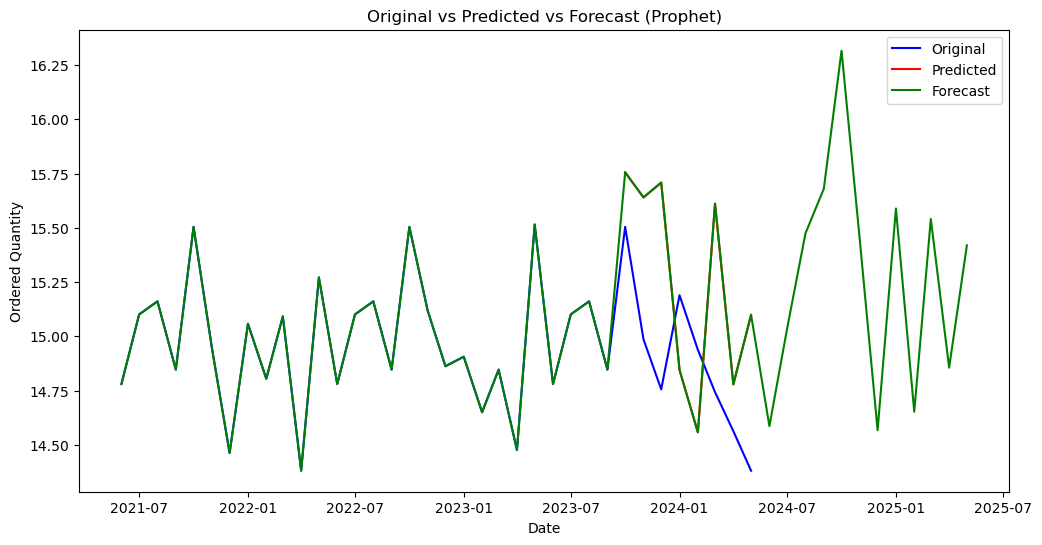

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Supposons que df_log est votre DataFrame contenant les données

# Convertir l'index en DatetimeIndex si nécessaire
df_log.index = pd.to_datetime(df_log.index)

# Rééchantillonner les données pour obtenir une fréquence mensuelle tout en gardant les valeurs d'origine
df_log = df_log.resample('MS').mean()

# Remplir les valeurs manquantes avec la méthode d'interpolation
df_log = df_log.interpolate(method='linear')

# Préparer les données pour Prophet
prophet_data = df_log.reset_index()
prophet_data.columns = ['ds', 'y']

# Définir la proportion de données à utiliser pour l'apprentissage
train_size = 0.8  # 80% des données pour l'apprentissage
split_index = int(len(prophet_data) * train_size)

# Diviser les données en ensembles d'apprentissage et de test
train_data = prophet_data.iloc[:split_index]
test_data = prophet_data.iloc[split_index:]

# Créer et ajuster le modèle Prophet avec des paramètres modifiés
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.5,
    seasonality_prior_scale=0.1
)
model.fit(train_data)

# Créer un DataFrame pour les dates futures
future = model.make_future_dataframe(periods=len(test_data), freq='MS')

# Effectuer des prédictions
forecast = model.predict(future)

# Calculer les métriques d'évaluation
predictions = forecast.iloc[split_index:]['yhat']
mae = mean_absolute_error(test_data['y'], predictions)
mse = mean_squared_error(test_data['y'], predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test_data['y'], predictions)

# Afficher les métriques
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Prédire les 20 mois à venir
future_forecast = model.predict(model.make_future_dataframe(periods=20, freq='MS'))

# Tracer les courbes
plt.figure(figsize=(12, 6))

# Courbe de la série originale
plt.plot(prophet_data['ds'], prophet_data['y'], label='Original', color='blue')

# Courbe des prédictions
plt.plot(test_data['ds'], predictions, label='Predicted', color='red')

# Courbe des prévisions futures
plt.plot(future_forecast['ds'], future_forecast['yhat'], label='Forecast', color='green')

# Ajouter des légendes et des titres
plt.title('Original vs Predicted vs Forecast (Prophet)')
plt.xlabel('Date')
plt.ylabel('Ordered Quantity')
plt.legend()

# Afficher la courbe
plt.show()


Epoch 1/250


C:\Users\user\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\core\dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.3635 - val_loss: 0.4277
Epoch 2/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.4128 - val_loss: 0.4207
Epoch 3/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.3996 - val_loss: 0.4139
Epoch 4/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.3269 - val_loss: 0.4074
Epoch 5/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.3943 - val_loss: 0.4010
Epoch 6/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.3835 - val_loss: 0.3945
Epoch 7/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.3693 - val_loss: 0.3882
Epoch 8/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.3381 - val_loss: 0.3820
Epoch 9/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.3734 - val_loss: 0.3758
Epoch 10/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.3170 - val_loss: 0.3696
Epoch 11/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.3118 - val_loss: 0.3635
Epoch 12/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.3705 - val_loss: 0.3573
Epo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1024 - val_loss: 0.1100
Epoch 71/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0881 - val_loss: 0.1081
Epoch 72/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1185 - val_loss: 0.1062
Epoch 73/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0976 - val_loss: 0.1044
Epoch 74/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0860 - val_loss: 0.1028
Epoch 75/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1226 - val_loss: 0.1012
Epoch 76/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1259 - val_loss: 0.0996
Epoch 77/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1216 - val_loss: 0.0981
Epoch 78/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1457 - val_loss: 0.0968
Epoch 79/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1139 - val_loss: 0.0955
Epoch 80/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1135 - val_loss: 0.0943
Epoch 81/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1026 - val_loss: 

C:\Users\user\AppData\Local\Temp\ipykernel_51044\3114967957.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['predictions'] = predictions


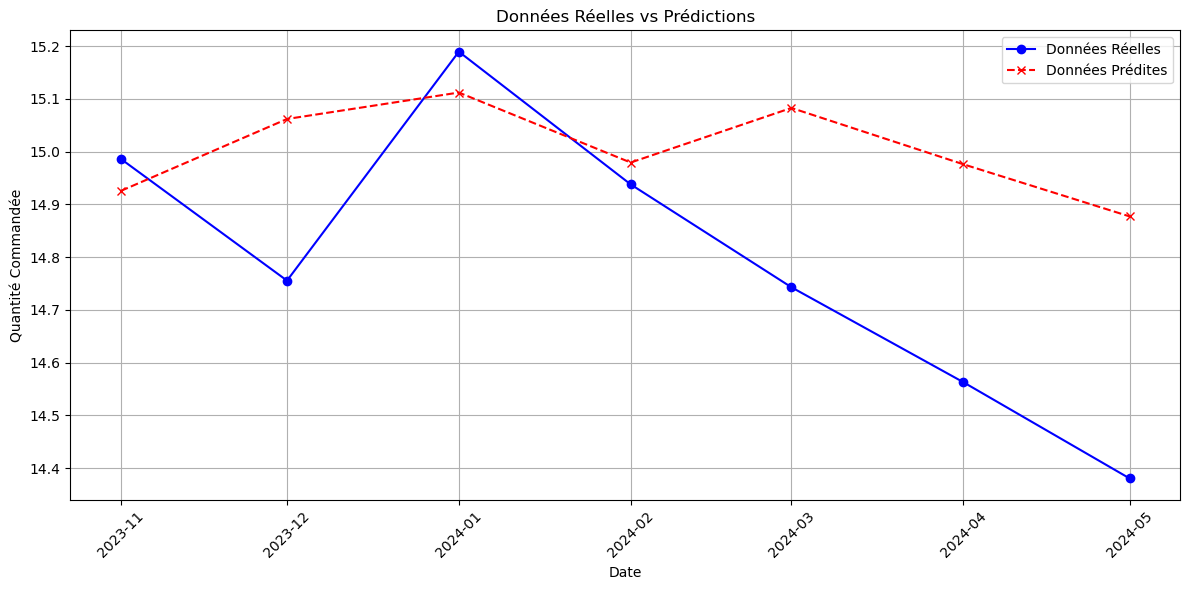

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Préparation des données
df_lagged = df_log.copy()
for lag in range(1, 6):  # Ajustez le nombre de lags selon vos besoins
    df_lagged[f'lag_{lag}'] = df_lagged['ordered_quantity'].shift(lag)
df_lagged = df_lagged.dropna()

# Diviser les données en ensembles d'apprentissage et de test
train_size = 0.8
split_index = int(len(df_lagged) * train_size)
train_data = df_lagged.iloc[:split_index]
test_data = df_lagged.iloc[split_index:]

# Séparer les features et la target
X_train = train_data.drop('ordered_quantity', axis=1)
y_train = train_data['ordered_quantity']
X_test = test_data.drop('ordered_quantity', axis=1)
y_test = test_data['ordered_quantity']

# Normalisation des données
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Création du modèle amélioré
model = Sequential()
model.add(Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dropout(0.2))  # Dropout pour éviter le surapprentissage
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Couche de sortie

# Compilation du modèle
model.compile(optimizer=Adam(learning_rate=0.0001), loss='mean_squared_error')

# Entraînement du modèle avec EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_scaled, y_train_scaled, epochs=250, batch_size=128, validation_split=0.5, callbacks=[early_stopping], verbose=1)

# Évaluation du modèle
loss = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f'Loss (MSE): {loss}')

# Prédictions
predictions_scaled = model.predict(X_test_scaled)
predictions = scaler_y.inverse_transform(predictions_scaled)
y_test_unscaled = scaler_y.inverse_transform(y_test_scaled)

# Calcul des métriques
mae = mean_absolute_error(y_test_unscaled, predictions)
mse = mean_squared_error(y_test_unscaled, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_unscaled, predictions)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Ajouter la colonne de date pour la visualisation
test_data['predictions'] = predictions

# Tracer les courbes
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, y_test_unscaled, label='Données Réelles', color='blue', linestyle='-', marker='o')
plt.plot(test_data.index, predictions, label='Données Prédites', color='red', linestyle='--', marker='x')
plt.xlabel('Date')
plt.ylabel('Quantité Commandée')
plt.title('Données Réelles vs Prédictions')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
